In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)




In [10]:
df = pd.read_csv('HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:


income_stay = df[df['Attrition'] == 'No']['MonthlyIncome']
income_leave = df[df['Attrition'] == 'Yes']['MonthlyIncome']

print('Mean Monthly Income (Stay):', income_stay.mean())
print('Mean Monthly Income (Leave):', income_leave.mean())




Mean Monthly Income (Stay): 6832.739659367397
Mean Monthly Income (Leave): 4787.0928270042195


In [12]:
stat_stay, p_stay = stats.shapiro(income_stay)
stat_leave, p_leave = stats.shapiro(income_leave)
print('\nNormality Test (Shapiro-Wilk):')
print(f'Stay group p-value: {p_stay:.4e}')
print(f'Leave group p-value: {p_leave:.4e}')


stat_levene, p_levene = stats.levene(income_stay, income_leave)
print(f'Levene test p-value: {p_levene:.4e}')


Normality Test (Shapiro-Wilk):
Stay group p-value: 5.9704e-34
Leave group p-value: 1.5025e-17
Levene test p-value: 1.1831e-04


In [13]:

stat_u, p_u = stats.mannwhitneyu(income_leave, income_stay, alternative='less')
print('Mann-Whitney U Test p-value:', p_u)


stat_t, p_t = stats.ttest_ind(income_leave, income_stay, equal_var=False, alternative='less')
print("Welch's T-Test p-value:", p_t)

Mann-Whitney U Test p-value: 1.4754154586444366e-14
Welch's T-Test p-value: 2.2167943141430354e-13


C:\Users\aryan\AppData\Local\Temp\ipykernel_23348\686520721.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[0], palette='Set2')


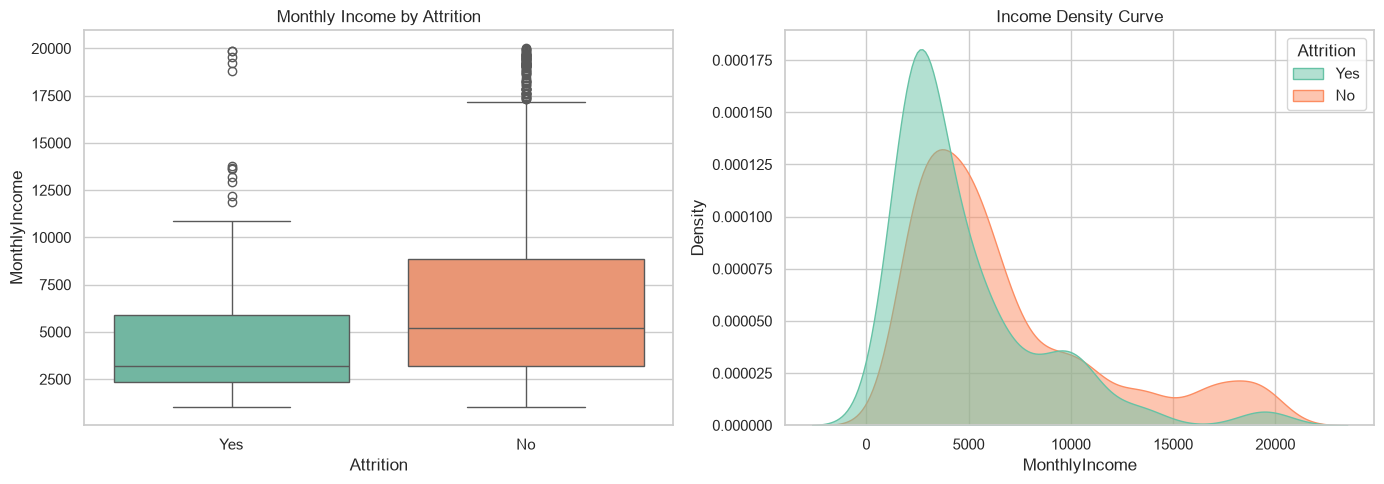

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Monthly Income by Attrition')

sns.kdeplot(data=df, x='MonthlyIncome', hue='Attrition', fill=True, common_norm=False, alpha=0.5, palette='Set2', ax=axes[1])
axes[1].set_title('Income Density Curve')

plt.tight_layout()
plt.show()

In [14]:

contingency = pd.crosstab(df['OverTime'], df['Attrition'])
print('Contingency Table:')
print(contingency)




Contingency Table:
Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127


In [15]:
prop = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
print('\nProportions (%):')
print(prop)


chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print('\nExpected frequencies:')
print(expected)
print('Chi-Square p-value:', p_val)


Proportions (%):
Attrition         No        Yes
OverTime                       
No         89.563567  10.436433
Yes        69.471154  30.528846

Expected frequencies:
[[884.06938776 169.93061224]
 [348.93061224  67.06938776]]
Chi-Square p-value: 8.15842372153832e-21


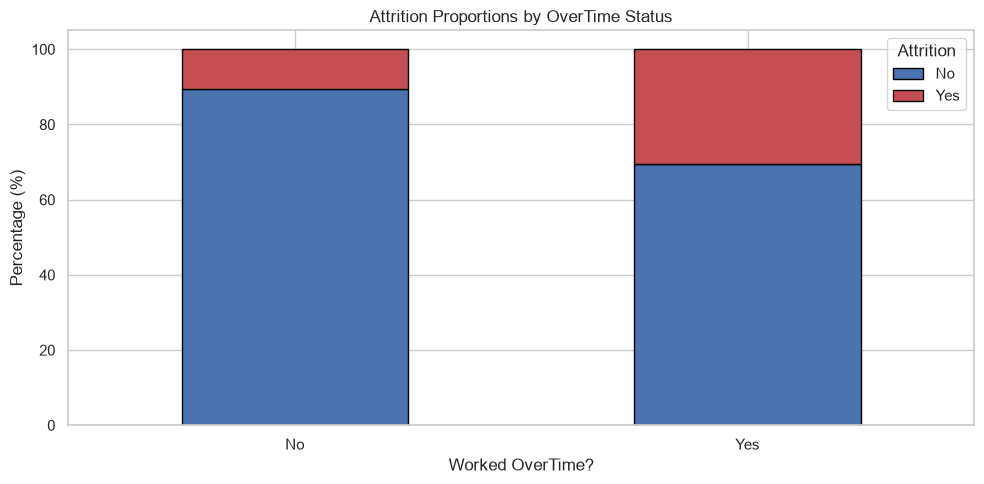

In [16]:

prop.plot(kind='bar', stacked=True, color=['#4c72b0', '#c44e52'], edgecolor='black')
plt.title('Attrition Proportions by OverTime Status')
plt.ylabel('Percentage (%)')
plt.xlabel('Worked OverTime?')
plt.xticks(rotation=0)
plt.legend(title='Attrition', loc='upper right')
plt.tight_layout()
plt.show()

In [18]:


satisfaction_stay = df[df['Attrition'] == 'No']['JobSatisfaction']
satisfaction_leave = df[df['Attrition'] == 'Yes']['JobSatisfaction']

print('Mean Job Satisfaction (Stay):', satisfaction_stay.mean())
print('Mean Job Satisfaction (Leave):', satisfaction_leave.mean())


stat_sat, p_sat = stats.mannwhitneyu(satisfaction_leave, satisfaction_stay, alternative='less')
print('Mann-Whitney U Test p-value:', p_sat)

Mean Job Satisfaction (Stay): 2.778588807785888
Mean Job Satisfaction (Leave): 2.4683544303797467
Mann-Whitney U Test p-value: 3.978958920445506e-05


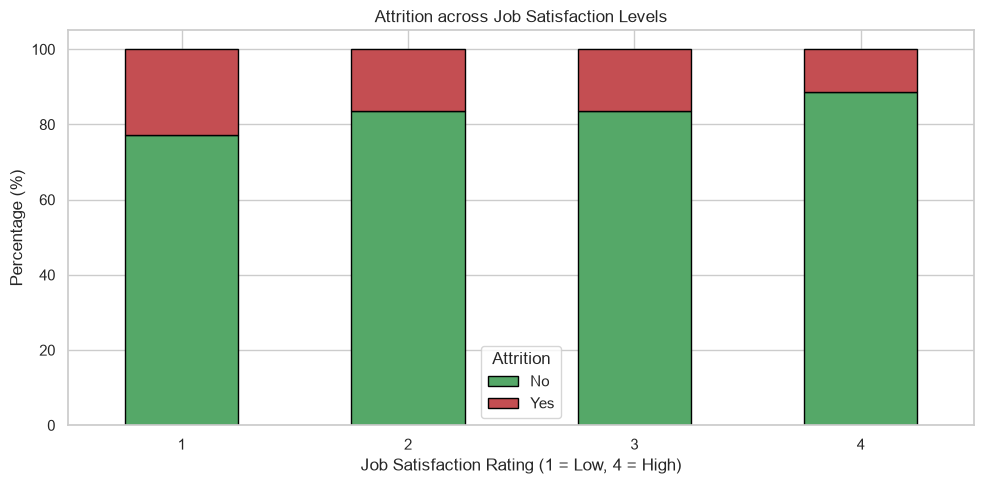

In [19]:

sat_prop = pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index') * 100
sat_prop.plot(kind='bar', stacked=True, color=['#55a868', '#c44e52'], edgecolor='black')
plt.title('Attrition across Job Satisfaction Levels')
plt.xlabel('Job Satisfaction Rating (1 = Low, 4 = High)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()